In [1]:
# checking file path and 
import sys
print(sys.executable)

/Users/shayma/Desktop/DS_Projects/medical-insurance-cost-prediction/.venv/bin/python


## Exploratory data analysis (Medical Insurance Costs)

##### Objective

The goal of this project is to predict the annual charges paid for medical insurance from demographic and lifestyle factors. We also aim to understand which of these features drive higher insurance costs. 


#### Installing Packages

In [2]:
# importing relevent python packages
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Loading the dataset


In [3]:
insurance_df = pd.read_csv('../data/insurance.csv')
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# observing the shape of the dataset
insurance_df.shape

(1338, 7)

In [5]:
insurance_df.sample(5)

,age,sex,bmi,children,smoker,region,charges
1257,54,female,27.645,1,no,northwest,11305.93455
538,46,female,28.050,1,no,southeast,8233.09750
347,46,male,33.345,1,no,northeast,8334.45755
127,52,female,37.400,0,no,southwest,9634.53800
1240,52,male,41.800,2,yes,southeast,47269.85400


In [6]:
# examining the information of the dataset
insurance_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


Of the 7 coloumns, it appears that we have 4 numerical features and 3 categorical features. 
The categorical features include:
- sex
- smoker
- region

In [7]:
# determining if there are missing values within the dataset
missing_values = insurance_df.isnull().sum().sort_values(ascending=False)   
missing_values


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

There are no misisng values within the dataset. 

In [8]:
# determining if there are duplicate values within the dataset
duplicate_values = insurance_df.duplicated().sum()
duplicate_values

np.int64(1)

In [9]:
print(f"Missing values in the dataset: {insurance_df.isnull().sum().sum()}")
print(f"Duplicate values in the dataset: {insurance_df.duplicated().sum()}")

Missing values in the dataset: 0
Duplicate values in the dataset: 1


#### Data analysis

In [10]:
# obtaining an overview of the statistical measures of the dataset
insurance_df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


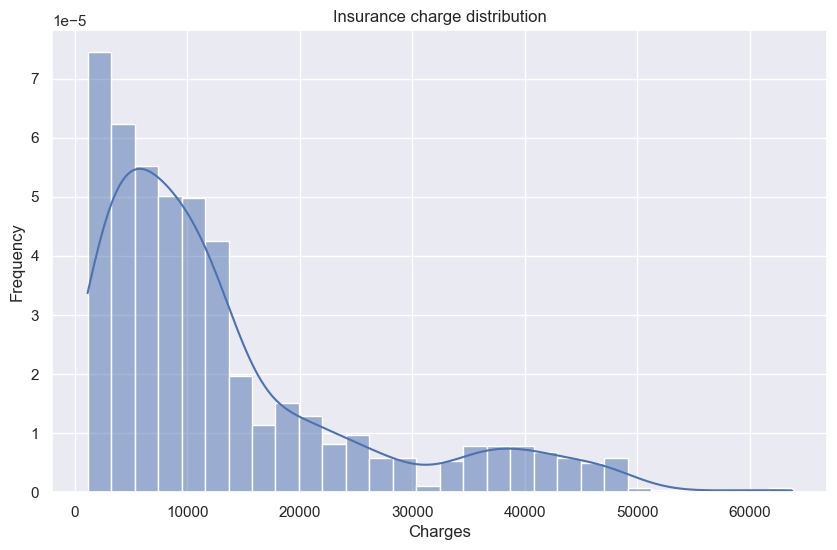

In [11]:
# Distribution of the insurance charges
sns.set_theme()
plt.figure(figsize=(10, 6))
sns.histplot(insurance_df['charges'], kde=True, stat='density')
plt.title('Insurance charge distribution')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

- The distribution of the charges is right-skewed (positively skewed) indicating that majority of the people pay relatively low to moderate costs while a smaller group pay a sustantially higher cost (there is a huge peak roughly between $2,000 and $12,000, fewer people pay above $30,000 and a very small number pay $50,000+.)
- The density curve highlights the presence of extreme values (which significantly stretch the distribution.)
- There is a smaller peak around the higher charges level and this suggests that there is a subgroup within the data.
- As a result of the distribution's skewness, the mean will not accurately be a measure of central tendency here. Therefore, median will be best. 
- As a result of this, log-transform would be applied to the charges to reduce the skewness and compress large values.

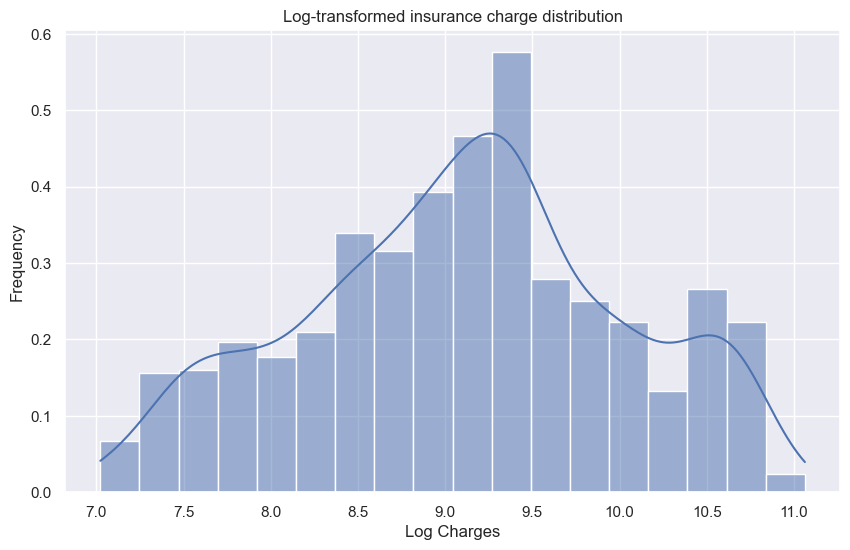

In [12]:
# log-transform the charges column to reduce skewness
insurance_df['log_charges'] = np.log(insurance_df['charges'])
# Distribution of the log-transformed insurance charges
plt.figure(figsize=(10, 6))
sns.histplot(insurance_df['log_charges'], kde=True, stat='density')
plt.title('Log-transformed insurance charge distribution')
plt.xlabel('Log Charges')
plt.ylabel('Frequency')
plt.show()

- After applyting the logarithmic transformation to the insurance charges, the distribution appears to be much more symmetric (skewness has reduced), the long tail as seen in the original plot has been comrpessed and the distribution looks closer to normal. 
- The transformation has reduced the impact of extreme high-cost values and has stabilised the variance. 
- The log-transform distribution better satisfies normality assumptions required for modelling.

##### Examining the distribution of the categorical variables

In [13]:
# observing the distribution of the categorical features
for col in ["sex", "smoker", "region"]:
            display(insurance_df[col].value_counts())

sex
male      676
female    662
Name: count, dtype: int64

smoker
no     1064
yes     274
Name: count, dtype: int64

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

- The dataset consist of 1,338 individuals and the sample composition of the categorical variables are shown above. The composition of sex and region variables are unremarkable. 
- The sample composition of the smoker group, however, is unbalanced as we have 1,064 non-smokers (79.5%) and 274 smokers (20.5%).
- Given the relationship between insurance costs and smokers, it is very likely the small smokers group may contribute to higher insurance charges.

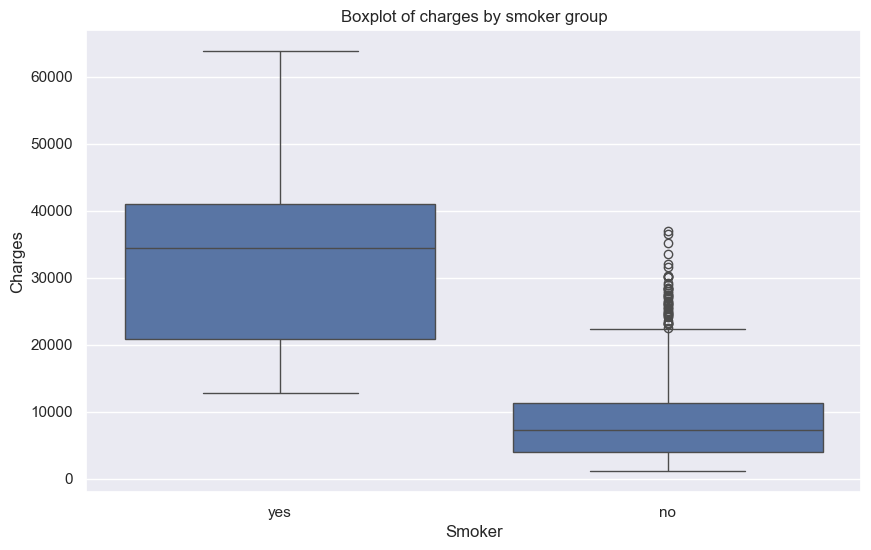

In [14]:
# examining the relationship between the insurance charges and the smokers
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=insurance_df)
plt.title('Boxplot of charges by smoker group')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

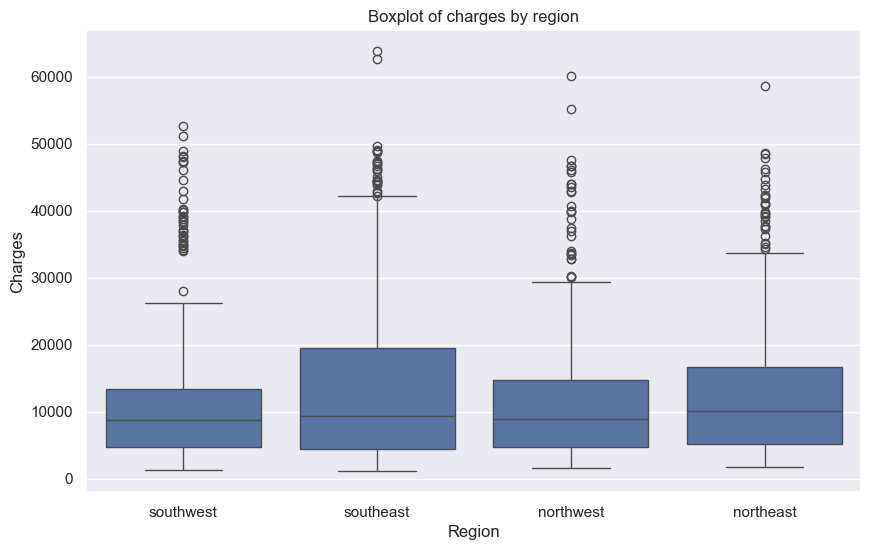

In [15]:
# examining the relationship between the insurance charges and region
plt.figure(figsize=(10, 6))
sns.boxplot(x='region', y='charges', data=insurance_df)
plt.title('Boxplot of charges by region')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.show()

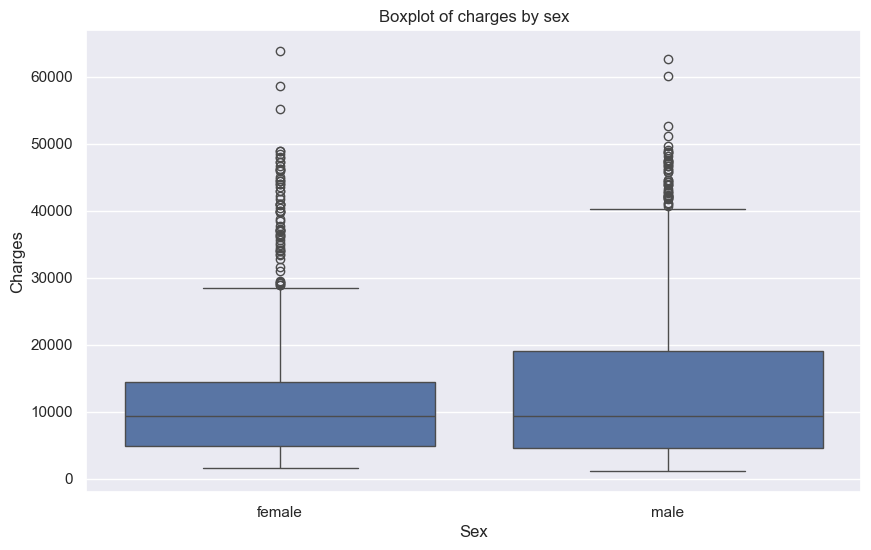

In [16]:
# examining the relationship between the insurance charges and sex
plt.figure(figsize=(10, 6))
sns.boxplot(x='sex', y='charges', data=insurance_df)
plt.title('Boxplot of charges by sex')
plt.xlabel('Sex')
plt.ylabel('Charges')
plt.show()  

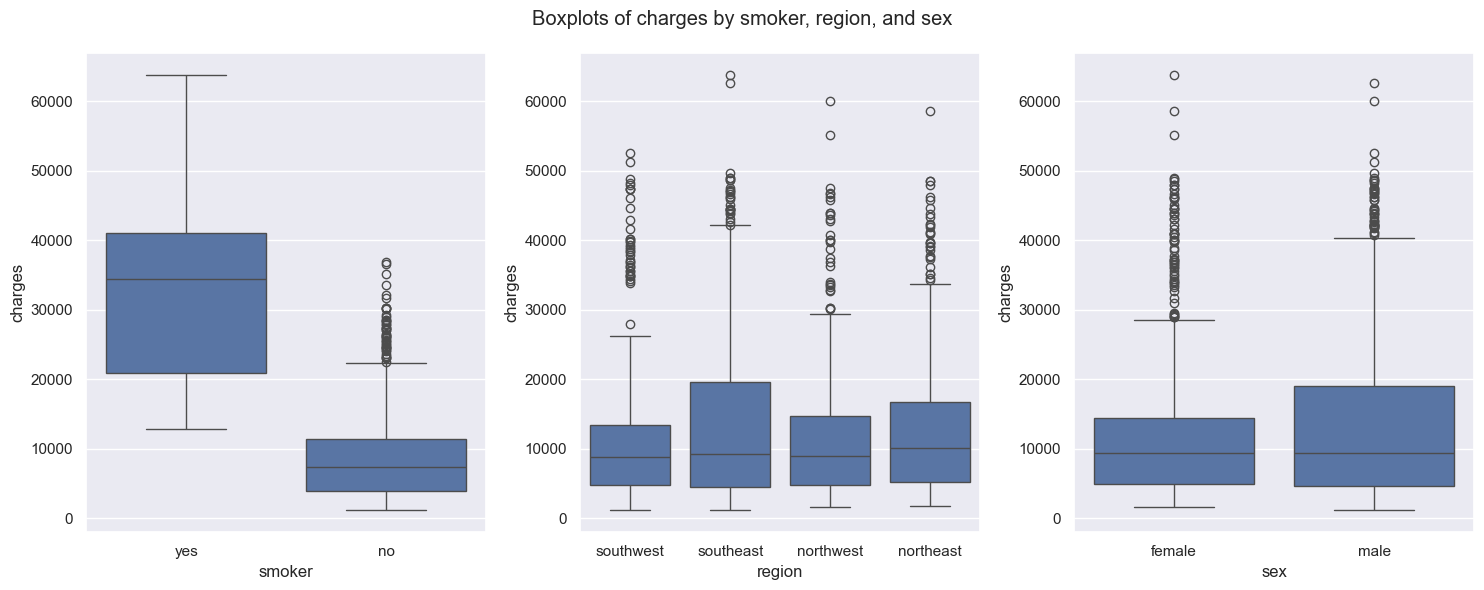

In [17]:
# visualising all the boxplots side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Boxplots of charges by smoker, region, and sex')
sns.boxplot(x='smoker', y='charges', data=insurance_df, ax=axes[0])
sns.boxplot(x='region', y='charges', data=insurance_df, ax=axes[1])
sns.boxplot(x='sex', y='charges', data=insurance_df, ax=axes[2])
plt.tight_layout()

##### Examining the distribution of the numerical variables

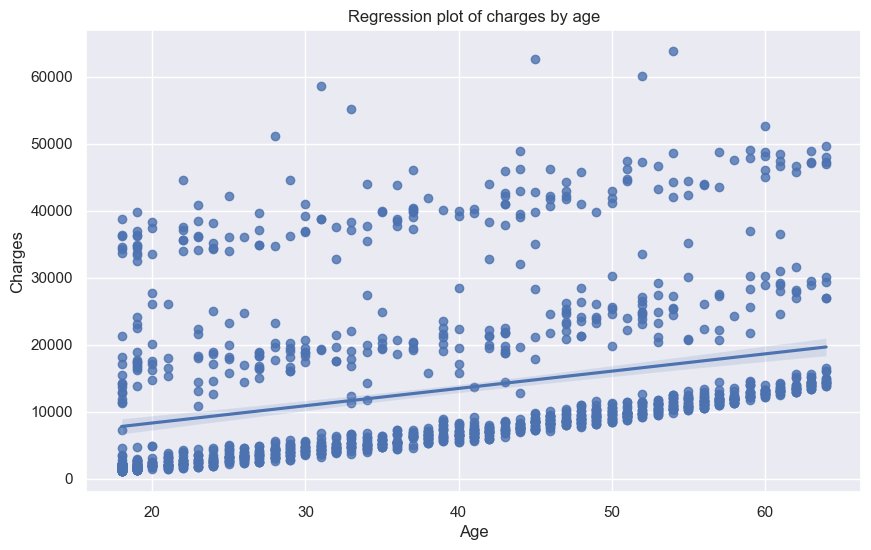

In [18]:
# examining the relationship between the insurance charges and age
plt.figure(figsize=(10, 6))
sns.regplot(x='age', y='charges', data=insurance_df)
plt.title('Regression plot of charges by age')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

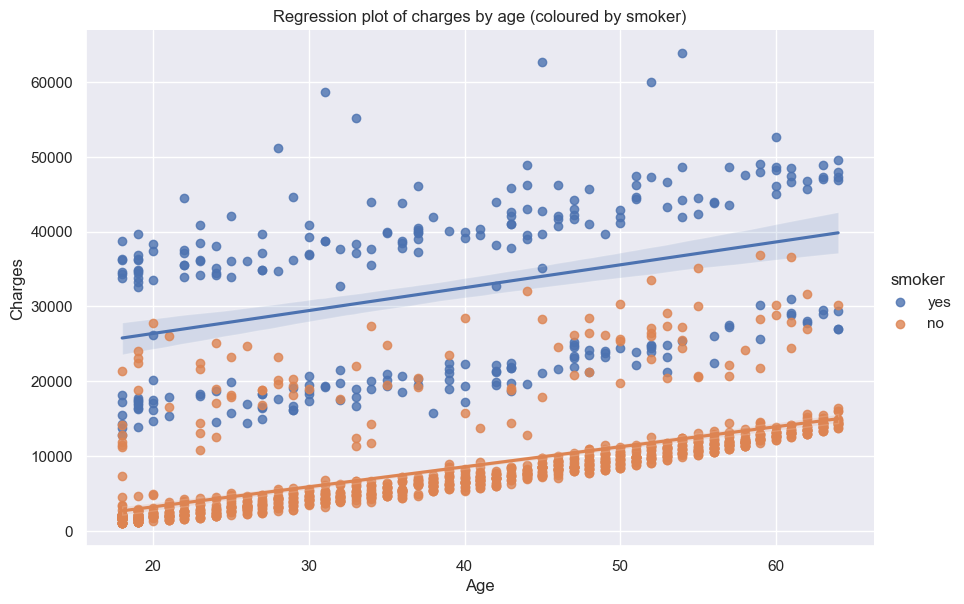

In [19]:
sns.lmplot(
    x='age',
    y='charges',
    # introducing hue, the factor we want to color by
    hue='smoker',
    #col='sex',
    #row='region',
    data=insurance_df,
    height=6,
    aspect=1.5
)

plt.title('Regression plot of charges by age (coloured by smoker)')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

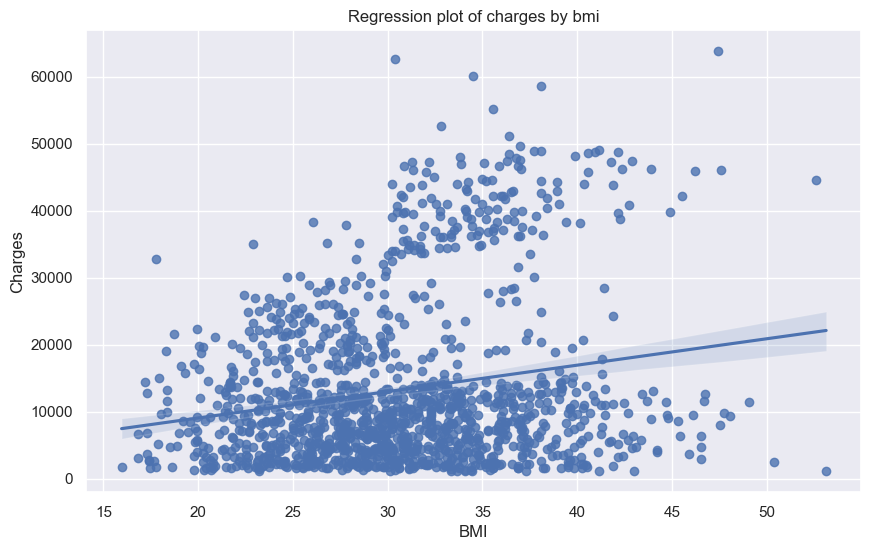

In [20]:
# examining the relationship between the insurance charges and bmi
plt.figure(figsize=(10, 6))
sns.regplot(x='bmi', y='charges', data=insurance_df)
plt.title('Regression plot of charges by bmi')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

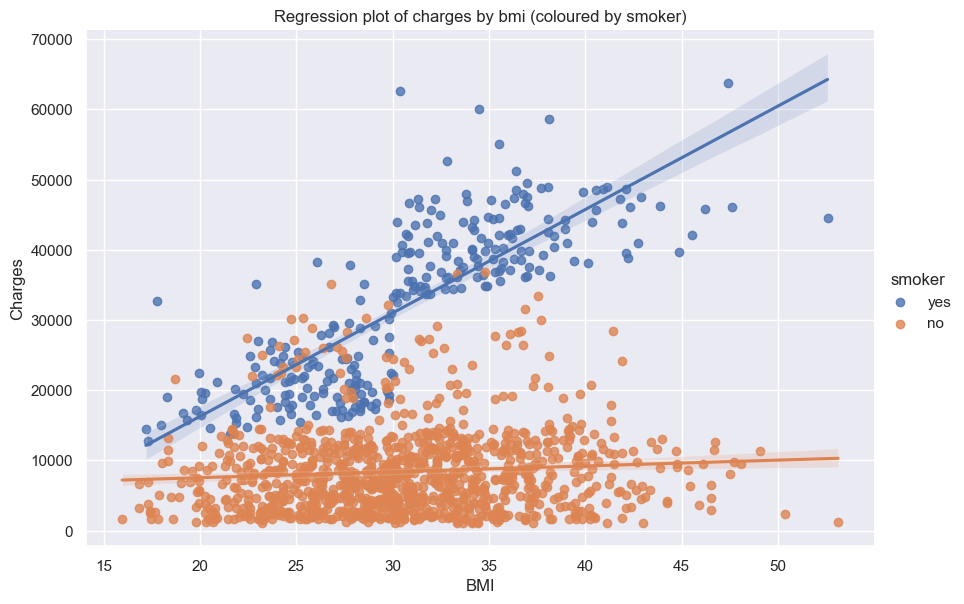

In [21]:
sns.lmplot(
    x='bmi',
    y='charges',
    # introducing hue, the factor we want to color by
    hue='smoker',
    #col='sex',
    data=insurance_df,
    height=6,
    aspect=1.5
)

plt.title('Regression plot of charges by bmi (coloured by smoker)')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

TypeError: lmplot() got an unexpected keyword argument 'ax'. Did you mean 'x'?

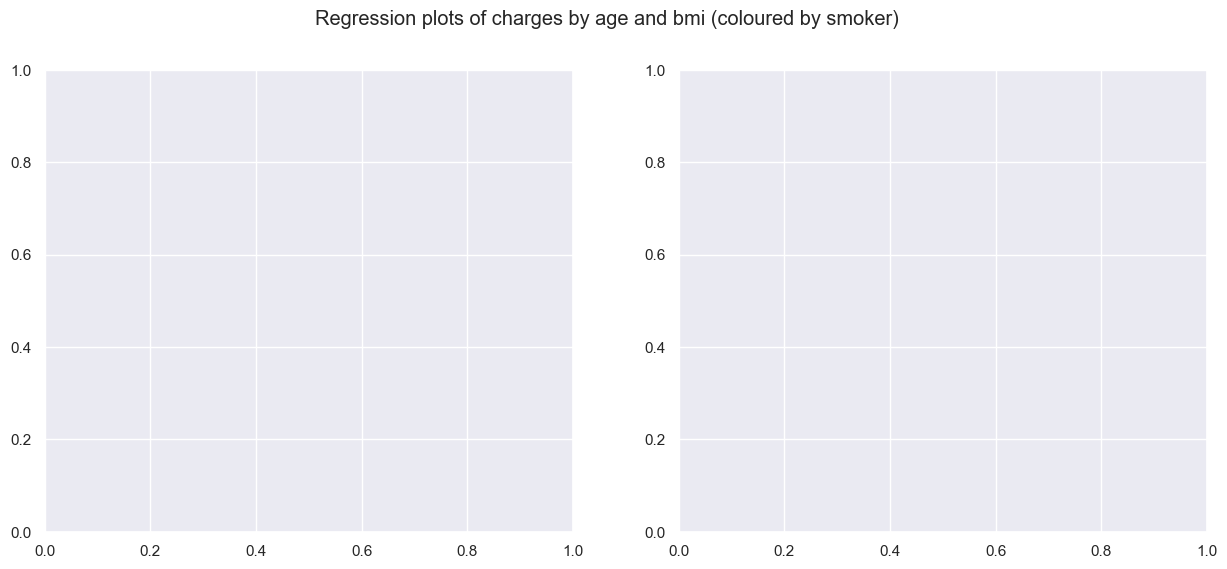

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Regression plots of charges by age and bmi (coloured by smoker)')
sns.lmplot(x='age', y='charges', hue='smoker', data=insurance_df, ax=axes[0])
sns.lmplot(x='bmi', y='charges', hue='smoker', data=insurance_df, ax=axes[1])
plt.tight_layout()

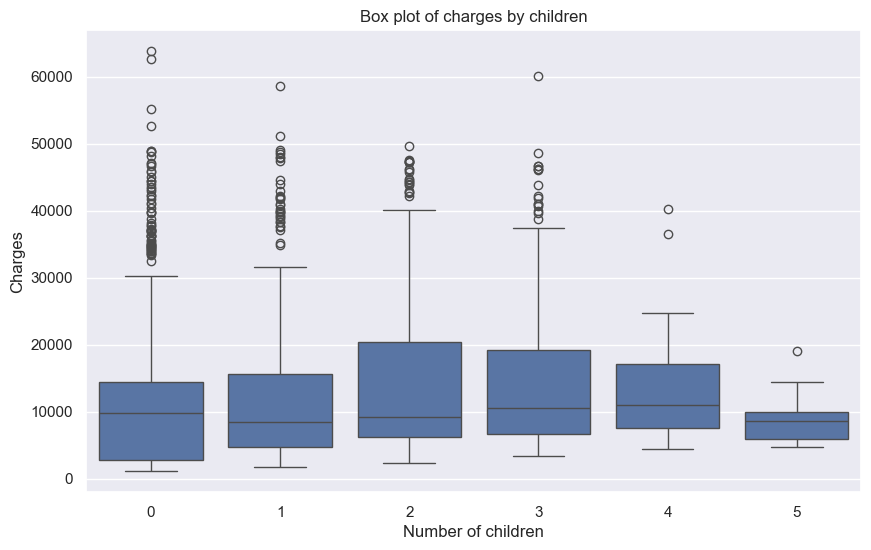

In [23]:
# examining the relationship between the insurance charges and children
plt.figure(figsize=(10, 6))
sns.boxplot(x='children', y='charges', data=insurance_df)
plt.title('Box plot of charges by children')
plt.xlabel('Number of children')
plt.ylabel('Charges')
plt.show()  

##### Correlation analysis



In [24]:
# selecting all numerical features for correlation analysis
# and encoding the categorical features for correlation analysis
#numerical_features = insurance_df.select_dtypes(include=[np.number])
#numerical_features.head()

insurance_df['sex'] = insurance_df['sex'].apply({'male':0, 'female':1}.get)
insurance_df['smoker'] = insurance_df['smoker'].apply({'no':0, 'yes':1}.get)
insurance_df['region'] = insurance_df['region'].apply({'southwest':0, 'southeast':1, 'northwest':2, 'northeast':3}.get)

insurance_df.head()



,age,sex,bmi,children,smoker,region,charges,log_charges
0,19,1,27.900,0,1,0,16884.92400,9.734176
1,18,0,33.770,1,0,1,1725.55230,7.453302
2,28,0,33.000,3,0,1,4449.46200,8.400538
3,33,0,22.705,0,0,2,21984.47061,9.998092
4,32,0,28.880,0,0,2,3866.85520,8.260197


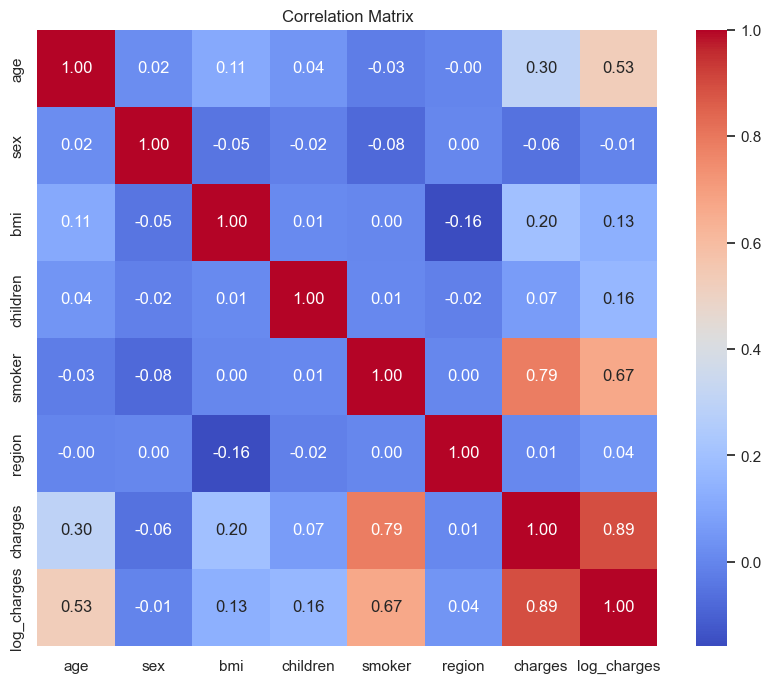

In [25]:
#computing the correlation matrix
correlation_matrix = insurance_df.corr()

# displaying the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

##### Checking for outliers by computing the IQR

In [26]:
# Checking for outliers by computing the IQR for the charges column
q1 = insurance_df['charges'].quantile(0.25)
q3 = insurance_df['charges'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = insurance_df[(insurance_df['charges'] < lower_bound) | (insurance_df['charges'] > upper_bound)]
print(f"Number of outliers in the charges column: {outliers.shape[0]}")

Number of outliers in the charges column: 139
